In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"
INTERIM_DATA = PROJECT_ROOT / "data" / "interim"

master_df = pd.read_csv(
    PROCESSED_DATA / "master_dataset.csv"
)

sales_clean = pd.read_csv(
    INTERIM_DATA / "sales_clean.csv",
    parse_dates=["InvoiceDate"]
)

print("Master dataset:", master_df.shape)
print("Sales dataset:", sales_clean.shape)

Master dataset: (3834, 18)
Sales dataset: (332664, 11)


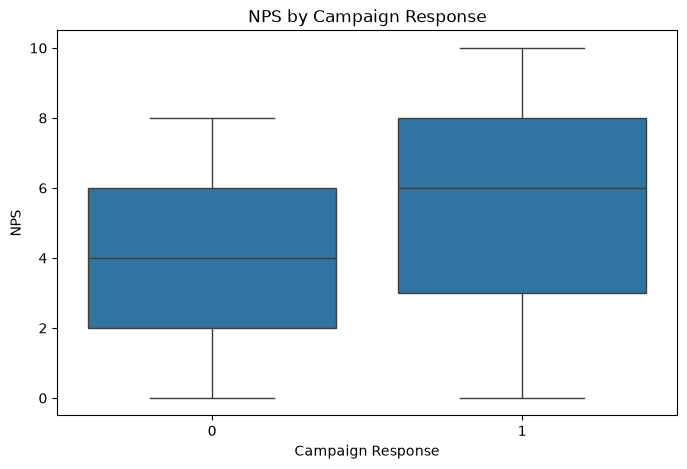

In [2]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=master_df,
    x="response",
    y="nps"
)

plt.title("NPS by Campaign Response")
plt.xlabel("Campaign Response")
plt.ylabel("NPS")

plt.show()

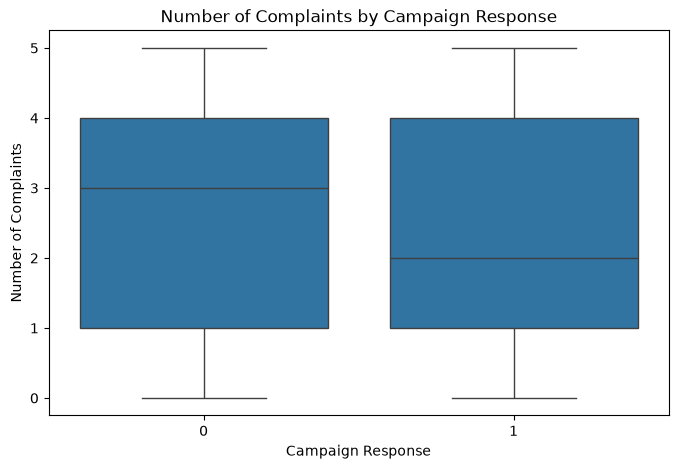

In [3]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=master_df,
    x="response",
    y="n_comp"
)

plt.title("Number of Complaints by Campaign Response")
plt.xlabel("Campaign Response")
plt.ylabel("Number of Complaints")

plt.show()

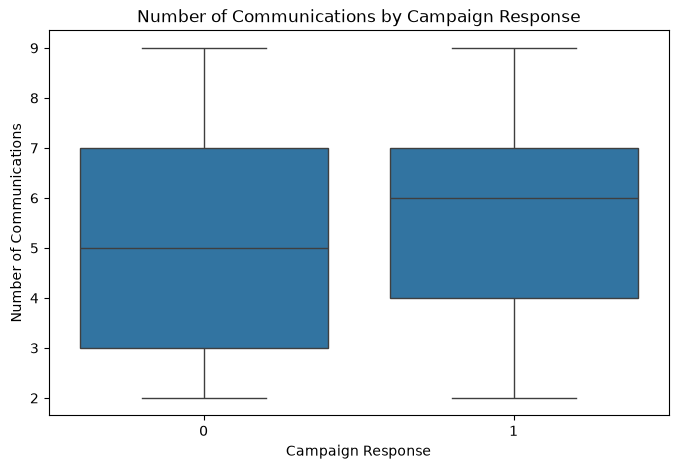

In [4]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=master_df,
    x="response",
    y="n_communications"
)

plt.title("Number of Communications by Campaign Response")
plt.xlabel("Campaign Response")
plt.ylabel("Number of Communications")

plt.show()

In [5]:
loyalty_response = (
    master_df
    .groupby("loyalty")["response"]
    .agg(
        total_customers="count",
        responders="sum",
        response_rate="mean"
    )
)

loyalty_response["response_rate"] *= 100

display(loyalty_response.round(2))

,total_customers,responders,response_rate
loyalty,,,
0,1648,525,31.86
1,2186,1030,47.12


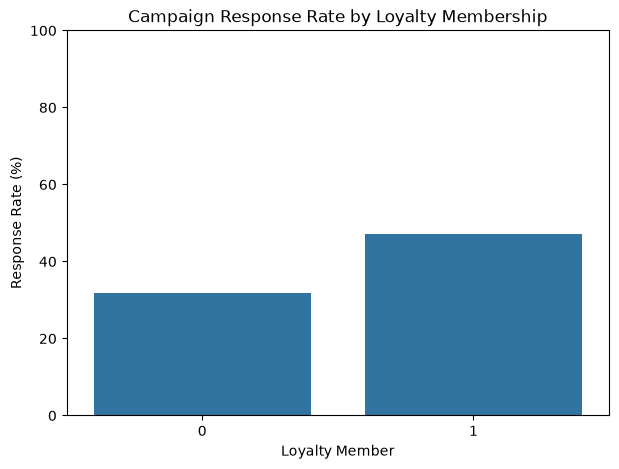

In [6]:
loyalty_plot = loyalty_response.reset_index()

plt.figure(figsize=(7, 5))

sns.barplot(
    data=loyalty_plot,
    x="loyalty",
    y="response_rate"
)

plt.title("Campaign Response Rate by Loyalty Membership")
plt.xlabel("Loyalty Member")
plt.ylabel("Response Rate (%)")
plt.ylim(0, 100)

plt.show()

In [7]:
nps_response = (
    master_df
    .groupby("nps_category", observed=False)["response"]
    .agg(
        total_customers="count",
        responders="sum",
        response_rate="mean"
    )
)

nps_response["response_rate"] *= 100

display(nps_response.round(2))

,total_customers,responders,response_rate
nps_category,,,
Detractor,2794,946,33.86
Passive,776,346,44.59
Promoter,261,261,100.00


In [8]:
nps_crosstab = pd.crosstab(
    master_df["nps_category"],
    master_df["response"]
)

display(nps_crosstab)

response,0,1
nps_category,,
Detractor,1848,946
Passive,430,346
Promoter,0,261


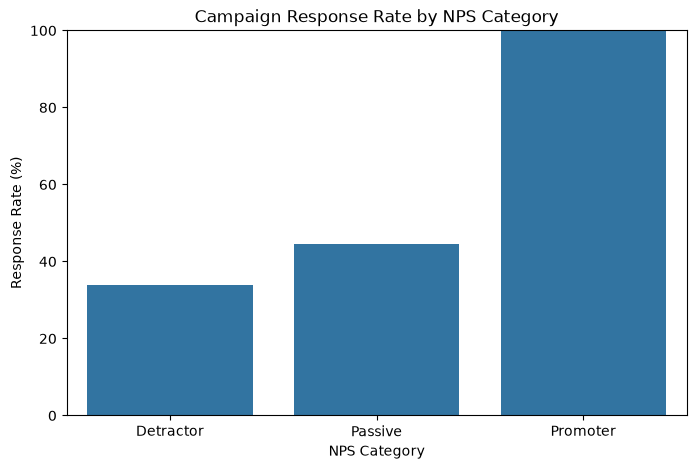

In [9]:
nps_plot = nps_response.reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    data=nps_plot,
    x="nps_category",
    y="response_rate"
)

plt.title("Campaign Response Rate by NPS Category")
plt.xlabel("NPS Category")
plt.ylabel("Response Rate (%)")
plt.ylim(0, 100)

plt.show()

In [10]:
purchase_response_summary = (
    master_df
    .groupby("response")[
        [
            "total_sales",
            "unique_products",
            "number_of_invoices"
        ]
    ]
    .median()
)

display(
    purchase_response_summary.round(2)
)

,total_sales,unique_products,number_of_invoices
response,,,
0,631.90,34.0,2.0
1,626.45,34.0,2.0


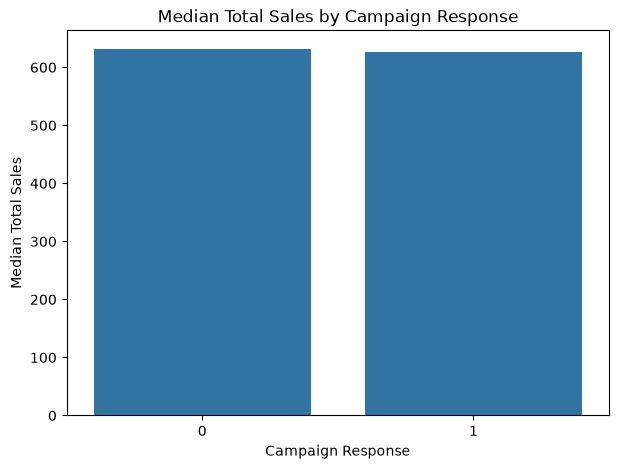

In [11]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=master_df,
    x="response",
    y="total_sales",
    estimator=np.median,
    errorbar=None
)

plt.title("Median Total Sales by Campaign Response")
plt.xlabel("Campaign Response")
plt.ylabel("Median Total Sales")

plt.show()

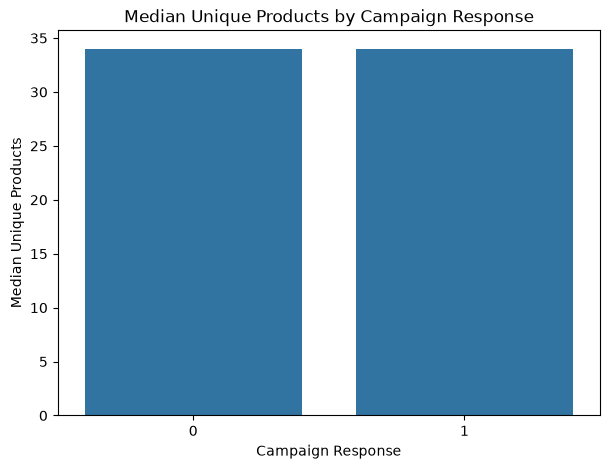

In [12]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=master_df,
    x="response",
    y="unique_products",
    estimator=np.median,
    errorbar=None
)

plt.title("Median Unique Products by Campaign Response")
plt.xlabel("Campaign Response")
plt.ylabel("Median Unique Products")

plt.show()

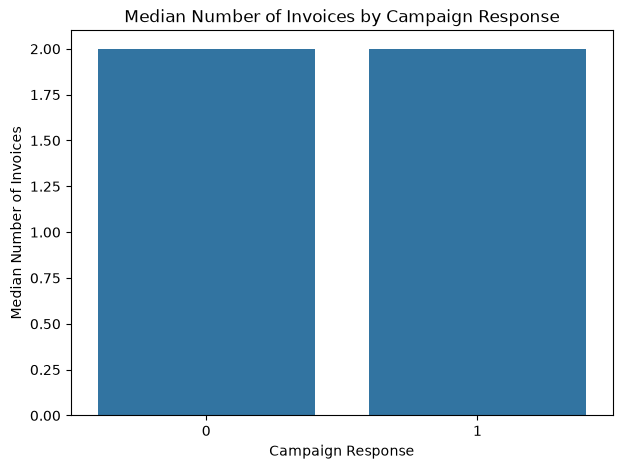

In [13]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=master_df,
    x="response",
    y="number_of_invoices",
    estimator=np.median,
    errorbar=None
)

plt.title("Median Number of Invoices by Campaign Response")
plt.xlabel("Campaign Response")
plt.ylabel("Median Number of Invoices")

plt.show()

In [14]:
sales_clean["month"] = (
    sales_clean["InvoiceDate"]
    .dt.to_period("M")
    .astype(str)
)

monthly_sales = (
    sales_clean
    .groupby("month")["line_total"]
    .sum()
    .reset_index()
)

display(monthly_sales)

,month,line_total
0,2023-01,350668.800
1,2023-02,347856.550
2,2023-03,455534.070
3,2023-04,375919.231
4,2023-05,524363.880
5,2023-06,471386.360
6,2023-07,460082.891
7,2023-08,475752.950
8,2023-09,774279.322
9,2023-10,781612.370


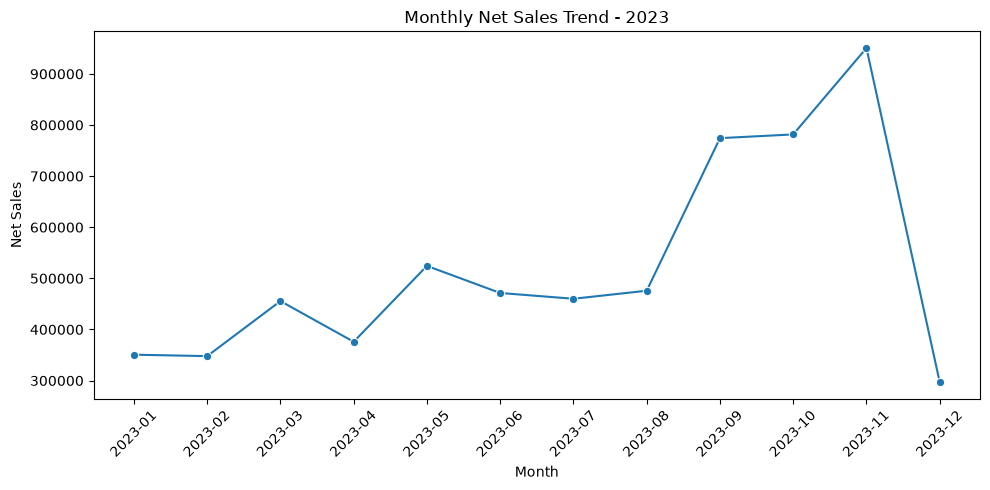

In [15]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly_sales,
    x="month",
    y="line_total",
    marker="o"
)

plt.title("Monthly Net Sales Trend - 2023")
plt.xlabel("Month")
plt.ylabel("Net Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [16]:
top_products = (
    sales_clean
    .groupby("Description")["line_total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

display(top_products)

,Description,line_total
0,REGENCY CAKESTAND 3 TIER,87797.50
1,WHITE HANGING HEART T-LIGHT HOLDER,80269.85
2,JUMBO BAG RED RETROSPOT,71839.53
3,PARTY BUNTING,61225.53
4,ASSORTED COLOUR BIRD ORNAMENT,48778.89
5,PICNIC BASKET WICKER 60 PIECES,39619.50
6,CHILLI LIGHTS,38954.67
7,PAPER CHAIN KIT 50'S CHRISTMAS,34997.33
8,DOORMAT KEEP CALM AND COME IN,33251.05
9,JUMBO BAG PINK POLKADOT,31821.74


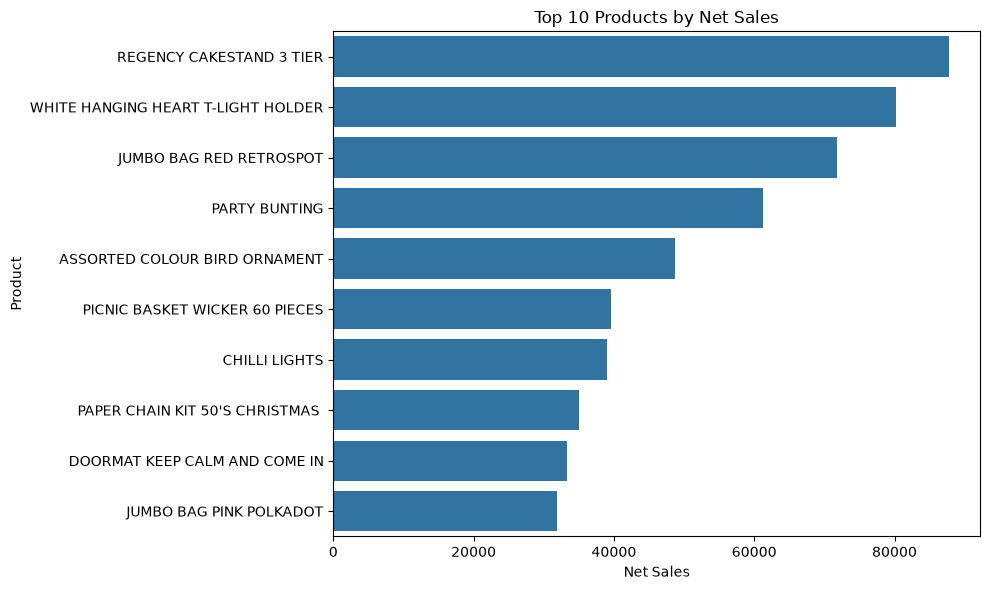

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_products,
    x="line_total",
    y="Description"
)

plt.title("Top 10 Products by Net Sales")
plt.xlabel("Net Sales")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [19]:
complaints_response = (
    master_df
    .groupby("n_comp")["response"]
    .agg(
        total_customers="count",
        responders="sum",
        response_rate="mean"
    )
)

complaints_response["response_rate"] *= 100

display(complaints_response.round(2))

,total_customers,responders,response_rate
n_comp,,,
0,377,157,41.64
1,641,275,42.90
2,785,377,48.03
3,852,296,34.74
4,778,326,41.90
5,401,124,30.92


In [20]:
communications_response = (
    master_df
    .groupby("n_communications")["response"]
    .agg(
        total_customers="count",
        responders="sum",
        response_rate="mean"
    )
)

communications_response["response_rate"] *= 100

display(communications_response.round(2))

,total_customers,responders,response_rate
n_communications,,,
2,350,109,31.14
3,566,139,24.56
4,548,227,41.42
5,587,249,42.42
6,560,267,47.68
7,449,220,49.00
8,539,240,44.53
9,235,104,44.26


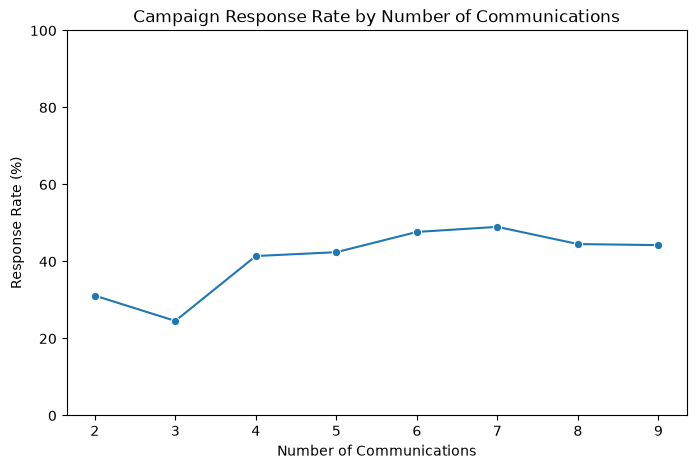

In [21]:
communications_plot = (
    communications_response
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=communications_plot,
    x="n_communications",
    y="response_rate",
    marker="o"
)

plt.title("Campaign Response Rate by Number of Communications")
plt.xlabel("Number of Communications")
plt.ylabel("Response Rate (%)")

plt.ylim(0, 100)

plt.show()

In [22]:
cancellation_response = (
    master_df
    .groupby("has_cancellation")["response"]
    .agg(
        total_customers="count",
        responders="sum",
        response_rate="mean"
    )
)

cancellation_response["response_rate"] *= 100

display(cancellation_response.round(2))

,total_customers,responders,response_rate
has_cancellation,,,
0,2511,1022,40.70
1,1323,533,40.29


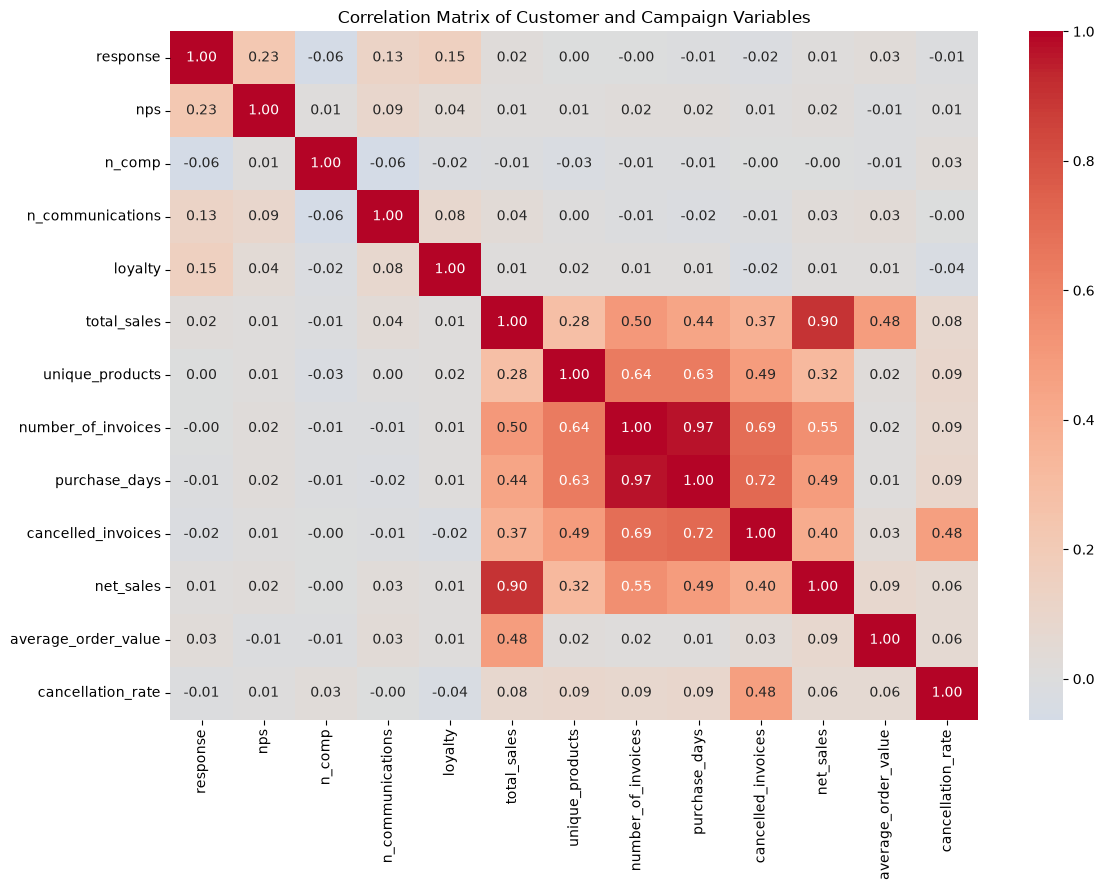

In [23]:
correlation_columns = [
    "response",
    "nps",
    "n_comp",
    "n_communications",
    "loyalty",
    "total_sales",
    "unique_products",
    "number_of_invoices",
    "purchase_days",
    "cancelled_invoices",
    "net_sales",
    "average_order_value",
    "cancellation_rate"
]

correlation_matrix = (
    master_df[correlation_columns]
    .corr()
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Customer and Campaign Variables")

plt.tight_layout()
plt.show()

<b> Key EDA Findings </b>

- Customers who responded to the campaign had a higher median NPS than non-responders.
- Loyalty programme members showed a substantially higher campaign response rate.
- Promoters (NPS 9–10) showed an exceptionally high response rate in this dataset.
- Customers who responded tended to have received more communications.
- The number of complaints showed a weaker and non-linear relationship with campaign response.
- Median total sales, unique products purchased, and number of invoices were very similar between responders and non-responders.
- Cancellation history showed almost no difference in campaign response rate.
- Monthly sales increased strongly from September to November, with November recording the highest net sales. December is incomplete because the dataset ends on 9 December.
- The highest-value product by net sales was REGENCY CAKESTAND 3 TIER.
- Strong correlations were identified between some transaction-derived features, particularly number_of_invoices and purchase_days, and total_sales and net_sales. These relationships should be reviewed for multicollinearity during modelling.